# Fashion-MNIST Diffusion Tutorial (Single-Class, Jupyter-Safe)

This notebook is a self-contained introduction to diffusion models on Fashion-MNIST, tuned for a single-class tutorial setting so that sampling works more easily in a notebook.

It covers:

1. the forward diffusion process,
2. the reverse-time process used for sampling,
3. a short discussion of DDPM vs. score-SDE notation,
4. the Anderson time-reversal result for diffusions,
5. Tweedie's lemma,
6. implementation of noise prediction / denoising score matching, and
7. reverse-process sampling.

This version is designed to be Jupyter-safe, single-class by default, and easier to train than the all-class version.

The default choice is:

- `target_class = 8`
- class name: `Bag`

This is one of the easiest Fashion-MNIST categories to model cleanly.

# 1. DDPM notation vs. score-SDE notation

In discrete time, DDPMs define a Markov chain

$$
q(x_t \mid x_{t-1}) = \mathcal{N}\!\bigl(x_t; \sqrt{\alpha_t}\,x_{t-1}, (1-\alpha_t)I \bigr),
$$

with

$$
\alpha_t = 1-\beta_t,
\qquad
\bar{\alpha}_t = \prod_{s=1}^t \alpha_s.
$$

Then

$$
q(x_t \mid x_0)
=
\mathcal{N}\!\bigl(x_t; \sqrt{\bar{\alpha}_t}\,x_0, (1-\bar{\alpha}_t)I \bigr),
$$

so

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon,
\qquad
\varepsilon \sim \mathcal{N}(0,I).
$$

In continuous time, one instead writes

$$
dX_t = f(X_t,t)\,dt + G(X_t,t)\,dW_t.
$$

In the isotropic setting,

$$
dX_t = f(X_t,t)\,dt + g(t)\,dW_t.
$$

The reverse-time dynamics depend on the score

$$
\nabla_x \log p_t(x).
$$

# 2. Forward process, Anderson reversal, and Tweedie

A forward diffusion gradually corrupts data into noise. In continuous time,

$$
dX_t = f(X_t,t)\,dt + g(t)\,dW_t.
$$

A standard variance-preserving example is

$$
dX_t = -\frac{1}{2}\beta(t)X_t\,dt + \sqrt{\beta(t)}\,dW_t.
$$

Conditioned on \( X_0=x_0 \), this has the Gaussian form

$$
X_t = \alpha(t)x_0 + \sigma(t)\varepsilon,
\qquad
\varepsilon \sim \mathcal{N}(0,I).
$$

If the forward diffusion has sufficiently regular positive densities \( p_t \), then the reversed process is again a diffusion whose drift contains the score correction

$$
-a(t)\nabla \log p_t(x),
\qquad
a(t)=G(t)G(t)^\top.
$$

In the isotropic case, this becomes

$$
f(x,t) - g(t)^2 \nabla \log p_t(x).
$$

Tweedie's lemma states that if

$$
Y = X + \sigma Z,
\qquad
Z \sim \mathcal{N}(0,I),
$$

with \( Z \) independent of \( X \), then

$$
\mathbb{E}[X \mid Y=y]
=
y + \sigma^2 \nabla \log p_Y(y).
$$

So denoising and score estimation are equivalent under Gaussian corruption.

# 3. Practical objective

Because

$$
x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\varepsilon,
$$

we can train a network \( \varepsilon_\theta(x_t,t) \) to predict \( \varepsilon \) using

$$
\mathcal{L}(\theta)
=
\mathbb{E}
\left[
\|\varepsilon_\theta(x_t,t)-\varepsilon\|^2
\right].
$$

This is the standard practical DDPM objective used below.

In [1]:
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

/Users/tomoleary/miniconda3/envs/torch/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/tomoleary/miniconda3/envs/torch/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /Users/tomoleary/miniconda3/envs/torch/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Users/tomoleary/miniconda3/envs/torch/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/tomoleary/miniconda3/envs/torch/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/tomoleary/miniconda3/envs/torch/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/tomoleary/miniconda3/envs/torch/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Othe

In [2]:
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [3]:
@dataclass
class Config:
    image_size: int = 28
    channels: int = 1
    batch_size: int = 128
    num_epochs: int = 15
    lr: float = 2e-4
    timesteps: int = 100
    beta_start: float = 1e-4
    beta_end: float = 2e-2
    train_subset: int | None = None
    test_subset: int | None = None
    num_workers: int = 0
    target_class: int | None = 8

cfg = Config()
cfg

Config(image_size=28, channels=1, batch_size=128, num_epochs=15, lr=0.0002, timesteps=100, beta_start=0.0001, beta_end=0.02, train_subset=None, test_subset=None, num_workers=0, target_class=8)

In [4]:
transform = transforms.ToTensor()

full_train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
full_test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

class_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

if cfg.target_class is not None:
    train_indices = [i for i, y in enumerate(full_train_ds.targets) if int(y) == cfg.target_class]
    test_indices = [i for i, y in enumerate(full_test_ds.targets) if int(y) == cfg.target_class]
    train_ds = Subset(full_train_ds, train_indices)
    test_ds = Subset(full_test_ds, test_indices)
    print(f"Using only class {cfg.target_class}: {class_names[cfg.target_class]}")
else:
    train_ds = full_train_ds
    test_ds = full_test_ds
    print("Using all Fashion-MNIST classes")

if cfg.train_subset is not None:
    train_ds = Subset(train_ds, list(range(min(cfg.train_subset, len(train_ds)))))
if cfg.test_subset is not None:
    test_ds = Subset(test_ds, list(range(min(cfg.test_subset, len(test_ds)))))

print("Train examples:", len(train_ds))
print("Test examples: ", len(test_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

print("train batches:", len(train_loader))
print("test batches:", len(test_loader))

Using only class 8: Bag
Train examples: 6000
Test examples:  1000
train batches: 47
test batches: 8


In [5]:
def to_model_space(x):
    return x * 2.0 - 1.0

def to_display_space(x):
    return ((x + 1.0) / 2.0).clamp(0.0, 1.0)

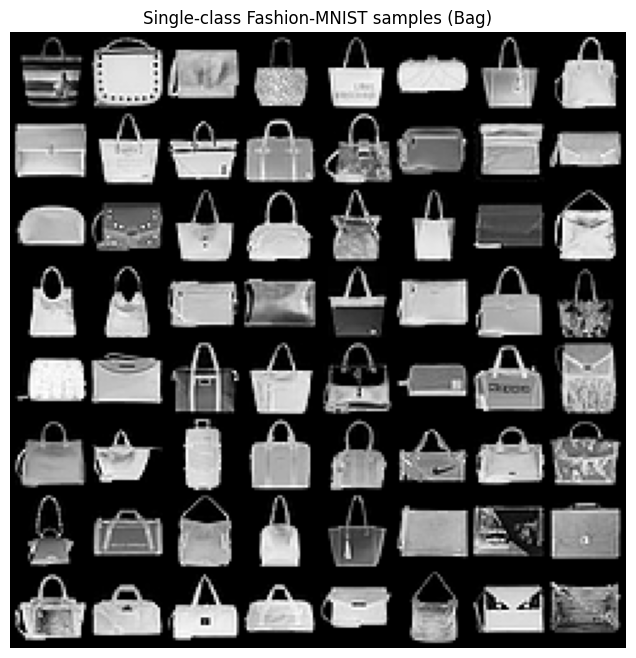

In [6]:
def show_batch(loader, title="Batch"):
    x, _ = next(iter(loader))
    x = to_model_space(x)
    grid = make_grid(to_display_space(x[:64]), nrow=8)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

title = "Single-class Fashion-MNIST samples"
if cfg.target_class is not None:
    title += f" ({class_names[cfg.target_class]})"

show_batch(train_loader, title)

# 4. Diffusion schedule and forward noising

In [7]:
betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.timesteps, dtype=torch.float32)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]], dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

betas = betas.to(device)
alphas = alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)
alphas_cumprod_prev = alphas_cumprod_prev.to(device)
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)
sqrt_recip_alphas = sqrt_recip_alphas.to(device)
posterior_variance = posterior_variance.to(device)

In [8]:
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(0, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise

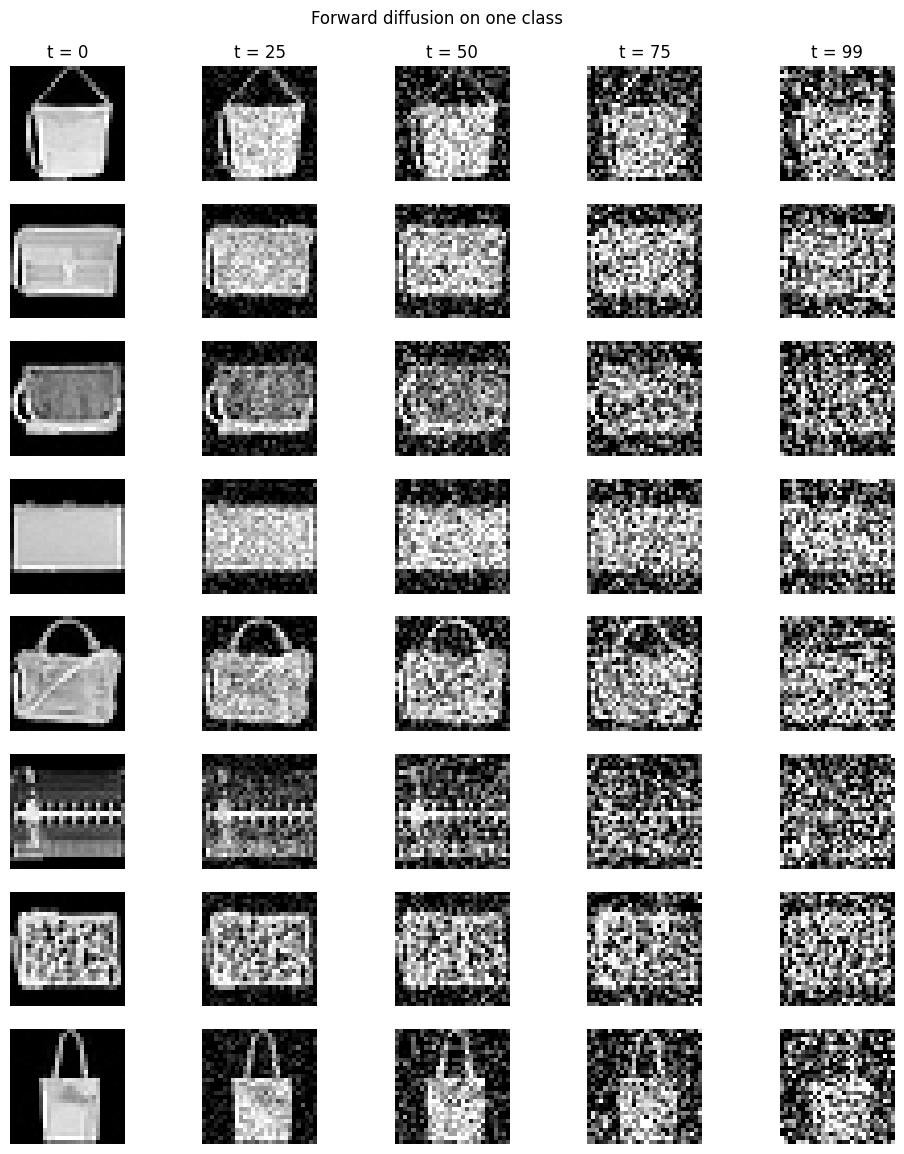

In [9]:
x0, _ = next(iter(train_loader))
x0 = to_model_space(x0[:8]).to(device)

times_to_show = [0, cfg.timesteps // 4, cfg.timesteps // 2, 3 * cfg.timesteps // 4, cfg.timesteps - 1]

fig, axes = plt.subplots(len(x0), len(times_to_show), figsize=(12, 14))
for row in range(len(x0)):
    for col, t_scalar in enumerate(times_to_show):
        t = torch.full((1,), t_scalar, device=device, dtype=torch.long)
        xt = q_sample(x0[row:row+1], t)
        img = to_display_space(xt[0].detach().cpu())
        axes[row, col].imshow(img.squeeze(), cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"t = {t_scalar}")

plt.suptitle("Forward diffusion on one class", y=0.92)
plt.show()

# 5. Time-conditioned network

In [10]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half_dim = self.dim // 2
        factor = math.log(10000) / max(half_dim - 1, 1)
        emb = torch.exp(torch.arange(half_dim, device=time.device) * -factor)
        emb = time[:, None].float() * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.act = nn.SiLU()
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.res_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.act(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.res_conv(x)

class SmallDiffusionCNN(nn.Module):
    def __init__(self, in_channels=1, base_channels=48, time_dim=128):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.in_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

        self.block1 = ResBlock(base_channels, base_channels, time_dim)
        self.block2 = ResBlock(base_channels, 2 * base_channels, time_dim)
        self.down1 = nn.Conv2d(2 * base_channels, 2 * base_channels, kernel_size=4, stride=2, padding=1)

        self.block3 = ResBlock(2 * base_channels, 2 * base_channels, time_dim)
        self.block4 = ResBlock(2 * base_channels, 4 * base_channels, time_dim)
        self.down2 = nn.Conv2d(4 * base_channels, 4 * base_channels, kernel_size=4, stride=2, padding=1)

        self.mid1 = ResBlock(4 * base_channels, 4 * base_channels, time_dim)
        self.mid2 = ResBlock(4 * base_channels, 4 * base_channels, time_dim)

        self.up1 = nn.ConvTranspose2d(4 * base_channels, 2 * base_channels, kernel_size=4, stride=2, padding=1)
        self.block5 = ResBlock(2 * base_channels, 2 * base_channels, time_dim)

        self.up2 = nn.ConvTranspose2d(2 * base_channels, base_channels, kernel_size=4, stride=2, padding=1)
        self.block6 = ResBlock(base_channels, base_channels, time_dim)

        self.out_conv = nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        x = self.in_conv(x)
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        x = self.down1(x)

        x = self.block3(x, t_emb)
        x = self.block4(x, t_emb)
        x = self.down2(x)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        x = self.up1(x)
        x = self.block5(x, t_emb)

        x = self.up2(x)
        x = self.block6(x, t_emb)

        return self.out_conv(x)

model = SmallDiffusionCNN(in_channels=cfg.channels).to(device)
print(f"parameters (millions): {sum(p.numel() for p in model.parameters()) / 1e6:.3f}")

parameters (millions): 3.657


# 6. Training

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

def diffusion_loss(model, x0):
    batch_size = x0.shape[0]
    t = torch.randint(0, cfg.timesteps, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise=noise)
    predicted_noise = model(xt, t)
    return F.mse_loss(predicted_noise, noise)

@torch.no_grad()
def predict_x0_from_eps(model, xt, t):
    eps_theta = model(xt, t)
    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, xt.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, xt.shape)
    x0_pred = (xt - sqrt_one_minus_alpha_bar_t * eps_theta) / sqrt_alpha_bar_t
    return x0_pred.clamp(-1.0, 1.0)

In [12]:
train_losses = []

for epoch in range(cfg.num_epochs):
    model.train()
    running_loss = 0.0

    for x0, _ in train_loader:
        x0 = to_model_space(x0).to(device)

        optimizer.zero_grad(set_to_none=True)
        loss = diffusion_loss(model, x0)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1:02d}/{cfg.num_epochs} - loss: {epoch_loss:.6f}")

Epoch 01/15 - loss: 0.792732
Epoch 02/15 - loss: 0.384880
Epoch 03/15 - loss: 0.276487
Epoch 04/15 - loss: 0.222300
Epoch 05/15 - loss: 0.200072
Epoch 06/15 - loss: 0.190301
Epoch 07/15 - loss: 0.187127
Epoch 08/15 - loss: 0.181100
Epoch 09/15 - loss: 0.176044
Epoch 10/15 - loss: 0.171963
Epoch 11/15 - loss: 0.167898
Epoch 12/15 - loss: 0.163809
Epoch 13/15 - loss: 0.165682
Epoch 14/15 - loss: 0.163085
Epoch 15/15 - loss: 0.161848


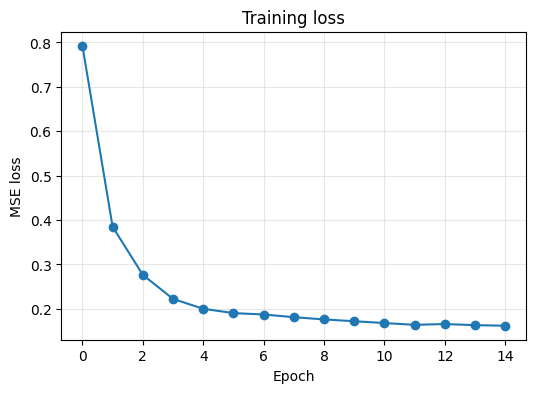

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

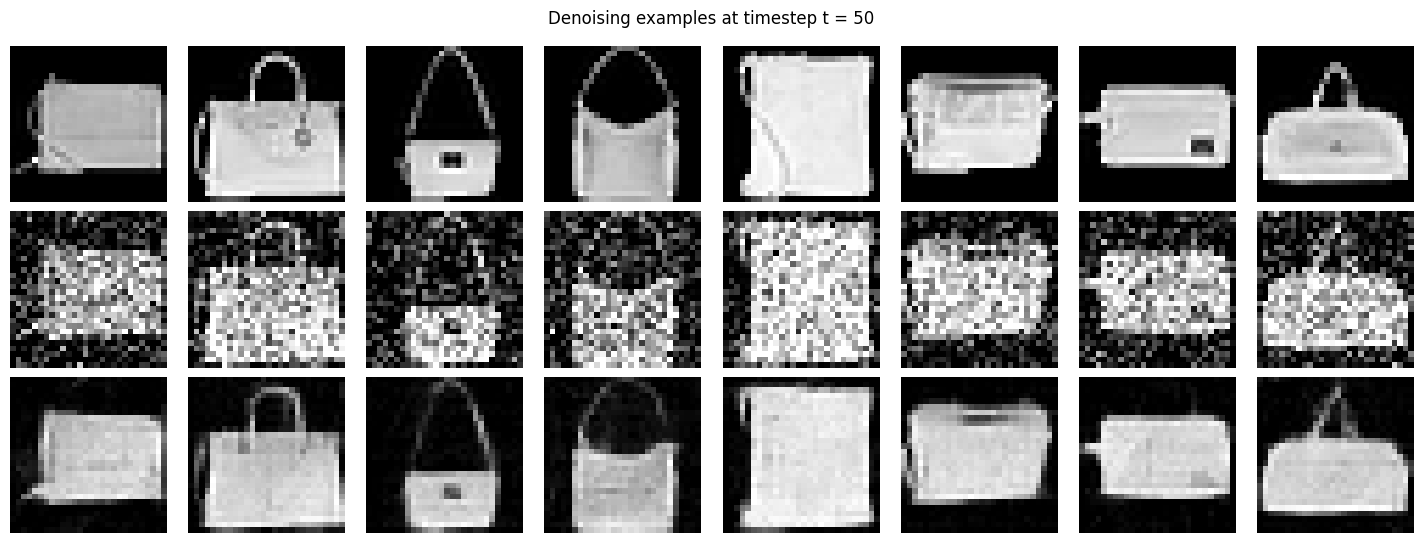

In [14]:
@torch.no_grad()
def show_denoising_examples(model, loader, timestep=None, n=8):
    model.eval()
    x0, _ = next(iter(loader))
    x0 = to_model_space(x0[:n]).to(device)

    if timestep is None:
        timestep = cfg.timesteps // 2

    t = torch.full((n,), timestep, device=device, dtype=torch.long)
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise=noise)
    x0_pred = predict_x0_from_eps(model, xt, t)

    fig, axes = plt.subplots(3, n, figsize=(1.8 * n, 5.5))
    for i in range(n):
        axes[0, i].imshow(to_display_space(x0[i].cpu()).squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(to_display_space(xt[i].cpu()).squeeze(), cmap="gray")
        axes[1, i].axis("off")
        axes[2, i].imshow(to_display_space(x0_pred[i].cpu()).squeeze(), cmap="gray")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("clean", rotation=90, fontsize=12)
    axes[1, 0].set_ylabel("noisy", rotation=90, fontsize=12)
    axes[2, 0].set_ylabel("denoised", rotation=90, fontsize=12)
    plt.suptitle(f"Denoising examples at timestep t = {timestep}")
    plt.tight_layout()
    plt.show()

show_denoising_examples(model, test_loader, timestep=cfg.timesteps // 2, n=8)

# 7. Reverse sampling

In [15]:
@torch.no_grad()
def p_sample(model, x, t):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alpha_bar_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x.shape)

    eps_theta = model(x, t)

    model_mean = sqrt_recip_alpha_t * (
        x - betas_t * eps_theta / sqrt_one_minus_alpha_bar_t
    )

    posterior_var_t = extract(posterior_variance, t, x.shape)
    nonzero_mask = (t != 0).float().reshape(x.shape[0], *((1,) * (len(x.shape) - 1)))
    noise = torch.randn_like(x)

    return model_mean + nonzero_mask * torch.sqrt(posterior_var_t) * noise

@torch.no_grad()
def sample_images(model, n=64, store_intermediate=False):
    model.eval()
    x = torch.randn(n, cfg.channels, cfg.image_size, cfg.image_size, device=device)

    intermediates = []
    for step in reversed(range(cfg.timesteps)):
        t = torch.full((n,), step, device=device, dtype=torch.long)
        x = p_sample(model, x, t)

        if store_intermediate and (step % max(cfg.timesteps // 8, 1) == 0 or step == cfg.timesteps - 1):
            intermediates.append(x.detach().cpu())

    x = x.clamp(-1.0, 1.0)
    if store_intermediate:
        return x, intermediates
    return x

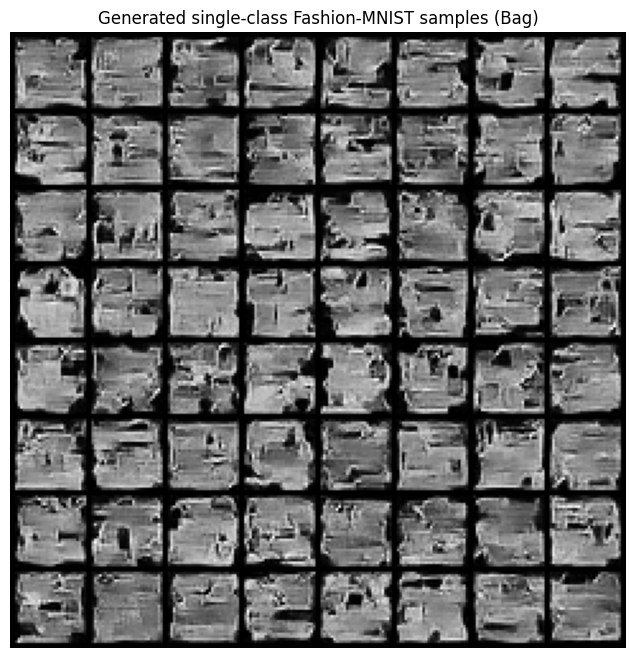

In [16]:
samples = sample_images(model, n=64)
grid = make_grid(to_display_space(samples.cpu()), nrow=8)

title = "Generated single-class Fashion-MNIST samples"
if cfg.target_class is not None:
    title += f" ({class_names[cfg.target_class]})"

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title(title)
plt.show()

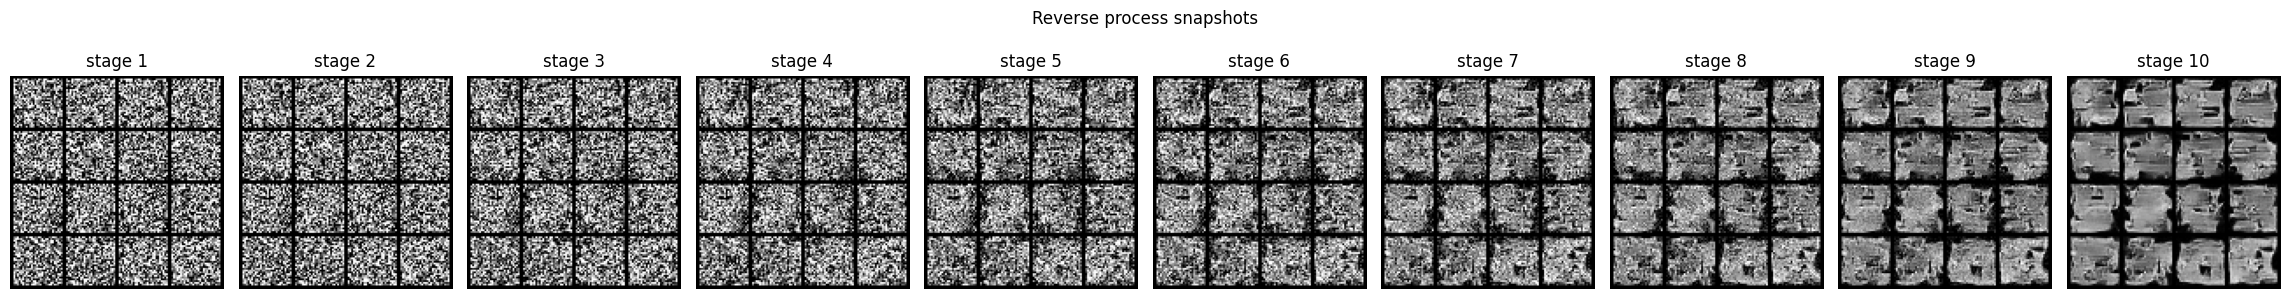

In [17]:
final_samples, intermediates = sample_images(model, n=16, store_intermediate=True)

fig, axes = plt.subplots(1, len(intermediates), figsize=(2.3 * len(intermediates), 3))
for i, imgs in enumerate(intermediates):
    grid = make_grid(to_display_space(imgs[:16]), nrow=4)
    axes[i].imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"stage {i+1}")

plt.suptitle("Reverse process snapshots", y=1.02)
plt.tight_layout()
plt.show()

# 8. Suggestions

If the samples are still rough, try:

1. increasing `num_epochs` to 20 or 30,
2. keeping `target_class = 8` for Bag,
3. trying `target_class = 1` for Trouser,
4. trying `target_class = 9` for Ankle boot.